# NumPy Intermedio

En el notebook anterior aprendimos qué es NumPy, sus ventajas sobre las listas de Python y cómo crear `ndarray`s de distintas formas. En esta parte vamos a entrar de lleno en cómo **manipular, operar y consultar** esos arreglos.

Los temas que cubriremos:

1. Atributos de los arreglos
2. Indexing y Slicing (1D y 2D)
3. Reshaping
4. Operaciones aritméticas vectorizadas
5. Universal Functions (ufuncs)
6. Agregaciones y estadísticas
7. Broadcasting
8. Boolean Indexing y Fancy Indexing

In [ ]:
import numpy as np
print(f"NumPy version: {np.__version__}")

---
# 1. Atributos de los Arreglos

Todo `ndarray` expone atributos que te dan información sobre su estructura **sin ejecutar ninguna operación**. Conocerlos te ayuda a debuggear shapes y entender cuánta memoria estás usando.

In [ ]:
# Creemos un arreglo 3D para explorar sus atributos
arr = np.random.randint(0, 100, size=(3, 4, 5))

print(f"ndim     : {arr.ndim}")       # número de dimensiones
print(f"shape    : {arr.shape}")      # tamaño en cada dimensión
print(f"size     : {arr.size}")       # total de elementos
print(f"dtype    : {arr.dtype}")      # tipo de dato
print(f"itemsize : {arr.itemsize}")   # bytes por elemento
print(f"nbytes   : {arr.nbytes}")     # bytes totales = size * itemsize

In [ ]:
# nbytes es sumamente relevante para saber cuánta memoria ocupa un arreglo
# Comparemos int64 vs int32 vs int8 en el mismo arreglo

a64 = np.zeros((1000, 1000), dtype=np.int64)
a32 = np.zeros((1000, 1000), dtype=np.int32)
a8  = np.zeros((1000, 1000), dtype=np.int8)

print(f"int64 : {a64.nbytes / 1e6:.1f} MB")
print(f"int32 : {a32.nbytes / 1e6:.1f} MB")
print(f"int8  : {a8.nbytes  / 1e6:.1f} MB")

---
# 2. Indexing y Slicing

Acceder a elementos o subconjuntos de un arreglo. La sintaxis es similar a las listas de Python, pero se extiende de forma muy natural a múltiples dimensiones.

## 2.1 Arreglos 1D

In [ ]:
arr1d = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

print(arr1d[0])      # primer elemento
print(arr1d[-1])     # último elemento
print(arr1d[2:6])    # slice: del índice 2 al 5 (el 6 no se incluye)
print(arr1d[::2])    # cada dos elementos (step=2)
print(arr1d[::-1])   # invertido

## 2.2 Arreglos 2D

Para múltiples dimensiones usamos comas: `arr[fila, columna]`

In [ ]:
arr2d = np.array([
    [1,  2,  3,  4],
    [5,  6,  7,  8],
    [9, 10, 11, 12]
])

print(arr2d[0, 0])    # fila 0, columna 0  → 1
print(arr2d[2, 3])    # fila 2, columna 3  → 12
print(arr2d[1, :])    # fila completa 1    → [5 6 7 8]
print(arr2d[:, 2])    # columna completa 2 → [3 7 11]
# Cada una de las reglas individuales de los índices se aplican
# a cada una de las dimensiones
print(arr2d[0:2, 1:3])  # submatriz filas 0-1, columnas 1-2

### ⚠️ Truncación

Recuerda que los arreglos de NumPy son de tipo fijo, es decir, que si intenamos asignar un valor de tipo diferente al que es el arreglo, pasarán cosas raras, como la truncación en el caso de que queramos asignar un número flotante a un arreglo de enteros, como en este caso:

In [ ]:
# Creamos un arreglo int
int_arr = np.array([1, 42, 609])

# Asignamos un numero float
int_arr[0] = 3.1415

print(int_arr)

### ⚠️ Los slices son VISTAS, no copias

Esta es una de las cosas más importantes de NumPy. Un slice **no** copia los datos, apunta al mismo bloque de memoria. Modificar el slice modifica el original.

In [ ]:
original = np.array([1, 2, 3, 4, 5])
vista = original[1:4]   # no copia datos

vista[0] = 99
print(original)  # [1, 99, 3, 4, 5] ← el original cambió!

In [ ]:
# Si necesitas una copia independiente, usa .copy()
original = np.array([1, 2, 3, 4, 5])
copia = original[1:4].copy()
copia[0] = 0
print(original)  # no cambia

---
# 3. Reshaping

Cambiar la forma de un arreglo sin cambiar sus datos. El número total de elementos (`size`) debe mantenerse igual.

> Nota importante: Recuerda que los arreglos de NumPy son de tamaño fijo, entonces cuando hacemos un "reshape" no es que estemos cambiando la forma de los arreglos originales, sino que estamos creando un nuevo arreglo con esas dimensiones nuevas (hay casos raros donde sí se modifica el original, pero espero que nunca te pase).

In [ ]:
base = np.arange(1, 13)   # [1, 2, 3, ..., 12]
print("Original:", base)

# Reshape a 3x4
m = base.reshape(3, 4)
print("\n3x4:\n", m)

# Reshape a 2x2x3
t = base.reshape(2, 2, 3)
print("\n2x2x3:\n", t)

In [ ]:
# Algo prohibido
p = base.reshape(3, 3)

In [ ]:
# El -1 en reshape significa "infiere esta dimensión automáticamente"
arr = np.arange(24)

print(arr.reshape(4, -1))    # 4 filas, columnas = 24/4 = 6
print()
print(arr.reshape(-1, 8))    # columnas=8, filas = 24/8 = 3

In [ ]:
# flatten() vs ravel()
# flatten() → siempre devuelve una copia
# ravel()   → devuelve una vista si es posible (más eficiente)

m = np.array([[1, 2, 3], [4, 5, 6]])

print(m.flatten())   # copia
print(m.ravel())     # vista (misma salida, diferente comportamiento en memoria)

In [ ]:
# np.newaxis: agregar una dimensión nueva (muy útil para broadcasting)
v = np.array([1, 2, 3])     # shape (3,)

col = v[:, np.newaxis]      # shape (3, 1) — vector columna
row = v[np.newaxis, :]      # shape (1, 3) — vector fila

print("Vector original shape:", v.shape)
print("Como columna shape:   ", col.shape)
print("Como fila shape:      ", row.shape)

# 3.5 ¿Para qué?
Es muy común que en el proceso de construcción de Pipelines de datos se necesiten modificar la forma (shape) de datos ingresados para:

- **Compatibilidad con modelos**: muchos modelos de ML esperan entradas con una forma específica, por ejemplo `(n_samples, n_features)` o `(batch, channels, height, width)` en redes convolucionales.
- **Agregar/quitar dimensiones**: pasar de `(n,)` a `(n, 1)` cuando un modelo espera una matriz y no un vector.
- **Aplanar tensores**: convertir una imagen `(28, 28)` en un vector `(784,)` antes de pasarla a una capa densa.
- **Reorganizar batches**: agrupar secuencias de datos en lotes `(batch_size, timesteps, features)` para modelos recurrentes (RNNs, LSTMs).
- **Pivotar datos**: convertir un array largo `(n_días * n_productos,)` en una matriz `(n_días, n_productos)` para análisis por producto.
- **Compatibilidad con librerías**: algunas herramientas como `scikit-learn`, `statsmodels` o APIs de bases de datos esperan shapes muy específicos y hay que adaptar la entrada.
- **Serialización y almacenamiento**: aplanar arrays antes de guardarlos en CSV o bases de datos relacionales, y reconstruirlos al leerlos.
- **Procesamiento por ventanas**: reorganizar series de tiempo en bloques `(n_ventanas, tamaño_ventana)` para calcular estadísticas deslizantes o detección de anomalías.

In [ ]:
import numpy as np

# Ventas diarias de 4 productos durante 6 días (serie plana)
ventas = np.array([10, 20, 15, 30, 25, 18, 22, 40, 12, 35, 28, 19,
                   11, 24, 17, 33, 27, 16, 20, 38, 14, 31, 26, 21])

print("Serie plana:", ventas.shape)          # (24,)

# Reorganizar a (6 días, 4 productos)
matriz = ventas.reshape(6, 4)

print("Matriz días × productos:\n", matriz)  # (6, 4)
print("Ventas promedio por producto:", matriz.mean(axis=0))
print("Venta total por día:         ", matriz.sum(axis=1))

---
# 4. Operaciones Aritméticas Vectorizadas

En NumPy los operadores `+`, `-`, `*`, `/`, `**` operan **elemento a elemento** sobre arreglos completos. Esto elimina la necesidad de escribir loops explícitos en Python.

In [2]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)
print("b / a  =", b / a)
print("a ** 2 =", a ** 2)
print("b % 3  =", b % 3)

NameError: name 'np' is not defined

In [ ]:
# Comparemos velocidad: loop Python vs operación NumPy
import time

N = 1_000_000
lista = list(range(N))
arreglo = np.arange(N)

# Loop Python
t10 = time.time()
new_list = []
for x in lista:
    new_list.append(x * 2)
t11 = time.time()

# Loop Python (list comprehension)
t20 = time.time()
resultado_python = [x * 2 for x in lista]
t21 = time.time()

# NumPy vectorizado
t2 = time.time()
resultado_numpy = arreglo * 2
t3 = time.time()

print(f"Python loop                      : {(t11-t10)*1000:.2f} ms")
print(f"Python loop (list comprehension) : {(t21-t20)*1000:.2f} ms")
print(f"NumPy                            : {(t3-t2)*1000:.2f} ms")

print(f"NumPy es ~{(t11-t10)/(t3-t2):.0f}x más rápido que python for loops")
print(f"NumPy es ~{(t21-t20)/(t3-t2):.0f}x más rápido que python list comprehension")

---
# 5. Universal Functions (ufuncs)

Las **ufuncs** son funciones que operan elemento a elemento sobre arreglos. Están implementadas en C, por lo que son muy rápidas. NumPy incluye un montón: trigonométricas, exponenciales, logarítmicas, de comparación, etc.

In [ ]:
x = np.array([1, 4, 9, 16, 25], dtype=float)

print("sqrt :", np.sqrt(x))
print("log  :", np.log(x))       # logaritmo natural
print("log2 :", np.log2(x))
print("log10:", np.log10(x))

In [ ]:
# Trigonométricas — trabajan en radianes (Basicamente trabajar con ángulos)
angulos = np.linspace(0, 2 * np.pi, 5)   # 0, π/2, π, 3π/2, 2π

print("ángulos (rad):", np.round(angulos, 4))
print("sin          :", np.round(np.sin(angulos), 4))
print("cos          :", np.round(np.cos(angulos), 4))

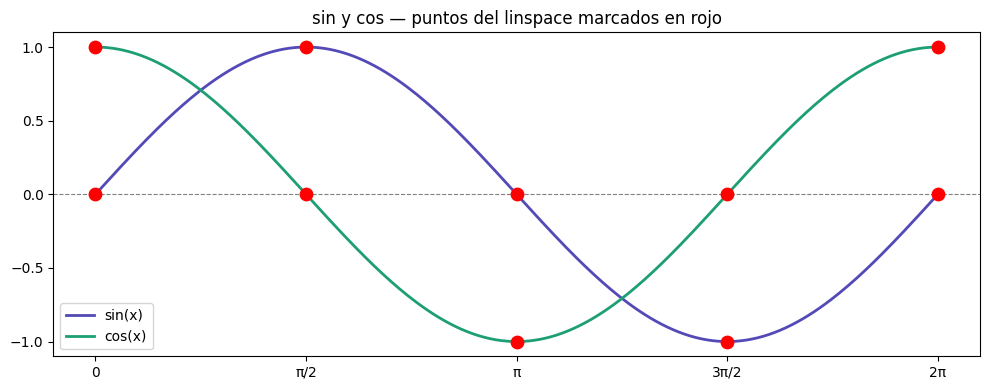

In [ ]:
# @title Default title text
import numpy as np
import matplotlib.pyplot as plt

angulos = np.linspace(0, 2 * np.pi, 5)
x = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, np.sin(x), color='#534AB7', linewidth=2, label='sin(x)')
ax.plot(x, np.cos(x), color='#1D9E75', linewidth=2, label='cos(x)')

ax.scatter(angulos, np.sin(angulos), color='red', zorder=5, s=80)
ax.scatter(angulos, np.cos(angulos), color='red', zorder=5, s=80)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(angulos)
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.legend()
ax.set_title('sin y cos — puntos del linspace marcados en rojo')

plt.tight_layout()
plt.savefig('trig.png', dpi=150)
plt.show()

In [ ]:
# Exponencial
x = np.array([0, 1, 2, 3])
print("exp(x):", np.exp(x))    # e^x

# Operaciones entre dos arreglos como ufuncs
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("maximum:", np.maximum(a, b))   # elemento a elemento
print("minimum:", np.minimum(a, b))
print("power  :", np.power(a, b))     # a^b elemento a elemento

---
# 6. Agregaciones y Estadísticas

Las agregaciones **reducen** un arreglo a un escalar (o a un arreglo de menor dimensión). NumPy tiene implementaciones muy optimizadas para todas las operaciones estadísticas básicas.

In [ ]:
datos = np.array([4, 7, 2, 9, 1, 5, 8, 3, 6])

print("sum  :", np.sum(datos))
print("min  :", np.min(datos))
print("max  :", np.max(datos))
print("mean :", np.mean(datos))
print("std  :", np.std(datos))       # desviación estándar
print("var  :", np.var(datos))       # varianza
print("median:",np.median(datos))
print("argmin:",np.argmin(datos))    # índice del mínimo
print("argmax:",np.argmax(datos))    # índice del máximo

## 6.1 Agregaciones por eje (axis)

En arreglos 2D puedes agregar a lo largo de filas o columnas con el parámetro `axis`.

- `axis=0` → opera **hacia abajo** (colapsa filas, resultado por columna)
- `axis=1` → opera **hacia los lados** (colapsa columnas, resultado por fila)

In [ ]:
m = np.array([
    [1, 2, 3, 4],
    [10, 20, 30, 40],
    [100, 200, 300, 400]
])

print("suma total     :", np.sum(m))           # escalar
print("suma axis=0    :", np.sum(m, axis=0))   # suma por columna → [12, 15, 18]
print("suma axis=1    :", np.sum(m, axis=1))   # suma por fila    → [6, 15, 24]
print("mean axis=0    :", np.mean(m, axis=0))  # promedio por columna

# Imagen de: https://medium.com/@NavSpeak/making-sense-of-numpy-axes-how-to-visualize-arrays-in-3d-13474aeaeca4

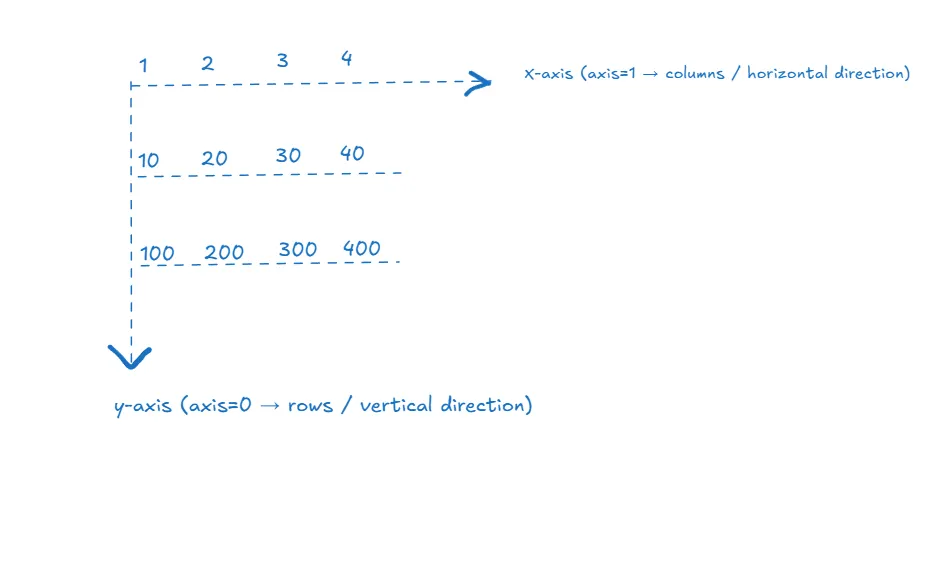

In [ ]:
# cumsum: suma acumulativa (no reduce, devuelve arreglo del mismo tamaño)
arr = np.array([1, 2, 3, 4, 5])
print("cumsum:", np.cumsum(arr))   # [1, 3, 6, 10, 15]
print("cumprod:", np.cumprod(arr)) # [1, 2, 6, 24, 120]

---
# 7. Broadcasting

Broadcasting es la mecánica que usa NumPy para operar entre arreglos de **shapes distintos**. En lugar de copiar datos para igualar tamaños, NumPy "estira" los arreglos más pequeños de forma virtual.

### Las reglas de Broadcasting

El broadcasting en NumPy sigue un conjunto estricto de reglas para determinar la interacción entre dos arrays:

- Regla 1: Si los dos arrays difieren en su número de dimensiones, la forma del que tiene menos dimensiones se rellena con unos por su lado izquierdo (leading side).
- Regla 2: Si la forma de los dos arrays no coincide en alguna dimensión, el array cuya forma sea igual a 1 en esa dimensión se estira para coincidir con la otra forma.
- Regla 3: Si en alguna dimensión los tamaños no coinciden y ninguno es igual a 1, se lanza un error.

[Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)

In [ ]:
# Caso 1: escalar + arreglo (el caso más intuitivo)
arr = np.arange(3)
# (3,) + (,) -> ...
print(arr + 5) # El 5 se broadcastea

In [ ]:
# Caso 2: arreglo 2D (3x3) + arreglo 1D (3,)

matriz = np.ones((3,3))
fila = np.arange(3)   # shape (3,)

# (3, 3) + (3,) -> ...
print("matriz.shape: ", matriz.shape)
print("fila.shape: ", fila.shape)
print("Suma fila a cada fila de la matriz:")
print(matriz + fila)

In [ ]:
# Caso 3: vector columna + vector fila → genera una matriz (outer product)
col = np.arange(3).reshape((3,1))
row = np.arange(3)

# (3, 1) + (3,) -> ...
resultado = col + row
print("Shape resultado:", resultado.shape)
print(resultado)

In [ ]:
# Ejemplo real: normalizar filas de una matriz
# (restar la media de cada fila)
datos = np.random.randint(0, 100, size=(4, 5)).astype(float)
medias = datos.mean(axis=1)[:, np.newaxis]   # shape (4,1)

normalizados = datos - medias   # broadcasting: (4,5) - (4,1) -> ...

print("Medias por fila:", medias.ravel())
print("Medias después de normalizar:", normalizados.mean(axis=1).round(10))

In [ ]:
# Ejempo negativo
M = np.ones((3, 2))
a = np.arange(3)

# (3, 2) + (3,)
print(M + a)

---
# 8. Boolean Indexing y Fancy Indexing

Estas dos técnicas te permiten seleccionar elementos de un arreglo de formas muy expresivas y poderosas. Son fundamentales en data wrangling con NumPy y pandas.

## 8.1 Boolean Indexing

In [ ]:
arr = np.array([15, 3, 42, 7, 28, 5, 33])

# Una comparación genera un arreglo de booleanos
mascara = arr > 10
header = " ".join(f"{v:>6}" for v in arr)
mask = " ".join(f"{str(b):>6}" for b in mascara)
post_header = " ".join(f"{v:>6}" for v in arr[mascara])

print(f"Arreglo        : {header}")
print(f"Máscara        : {mask}")
print(f"Arreglo despues: {post_header}")
print()

# Se puede hacer directo en una línea
print("Elementos pares:", arr[arr % 2 == 0])

In [ ]:
# Combinar condiciones con & (and) y | (or)
# OJO: usar & y | en lugar de 'and' y 'or', y envolver en paréntesis

arr = np.arange(1, 21)

# Números entre 5 y 15 que son impares
filtro = (arr >= 5) & (arr <= 15) & (arr % 2 != 0)
print(arr[filtro])

In [ ]:
# np.where: versión vectorizada de un if-else
# np.where(condición, valor_si_true, valor_si_false)

notas = np.array([45, 72, 88, 61, 90, 35, 78])
resultado = np.where(notas >= 60, "aprobado", "reprobado")
print(resultado)

## 8.2 Fancy Indexing

Pasar un arreglo (o lista) de **índices** para seleccionar elementos en un orden arbitrario. A diferencia de los slices, fancy indexing **siempre devuelve una copia**.

In [ ]:
arr = np.array([10, 20, 30, 40, 50, 60, 70])

indices = [0, 3, 6]          # seleccionar elementos en posiciones 0, 3, 6
print(arr[indices])          # [10, 40, 70]

# También funciona con orden arbitrario y repeticiones
print(arr[[4, 1, 4, 0]])     # [50, 20, 50, 10]

In [ ]:
# Fancy indexing en 2D para seleccionar filas específicas
m = np.random.randint(0, 100, size=(6, 4))
print("Matriz original:\n", m)

# Seleccionar filas 0, 2, 4 (las pares)
print("\nFilas 0, 2, 4:\n", m[[0, 2, 4]])

In [ ]:
# np.sort y argsort
arr = np.array([3, 1, 4, 1, 5, 9, 2, 6])

print("Ordenado:      ", np.sort(arr))
print("Índices orden: ", np.argsort(arr))  # índices que ordenarían el arreglo

# argsort es muy útil para ordenar un arreglo basado en otro
nombres  = np.array(["Carlos", "Ana", "Beatriz", "Diego"])
edades   = np.array([25, 30, 22, 28])

orden = np.argsort(edades)
print("\nNombres por edad:", nombres[orden])

---
# Resumen

| Tema | Lo que aprendiste |
|------|------------------|
| **Atributos** | `ndim`, `shape`, `size`, `dtype`, `itemsize`, `nbytes` |
| **Indexing** | `arr[i]`, `arr[i,j]`, slices, vistas vs copias |
| **Reshape** | `reshape()`, `ravel()`, `flatten()`, `np.newaxis` |
| **Operaciones** | Aritmética vectorizada sin loops en Python |
| **ufuncs** | `np.sqrt`, `np.exp`, `np.sin`, `np.maximum`... |
| **Agregaciones** | `sum`, `mean`, `std`, `argmin`, `cumsum`, `axis` |
| **Broadcasting** | Operar entre shapes distintas sin copiar datos |
| **Bool Indexing** | Filtrar con máscaras, `np.where` |
| **Fancy Indexing** | Selección por lista de índices, `argsort` |